<a href="https://colab.research.google.com/github/bollamanaswi/House-Price-Prediction/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
#ML libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [26]:
#load dataset
df=pd.read_csv("/content/House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [27]:
df.shape

(2000, 10)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [29]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [30]:
#check missing values
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [31]:
df=df.dropna()
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


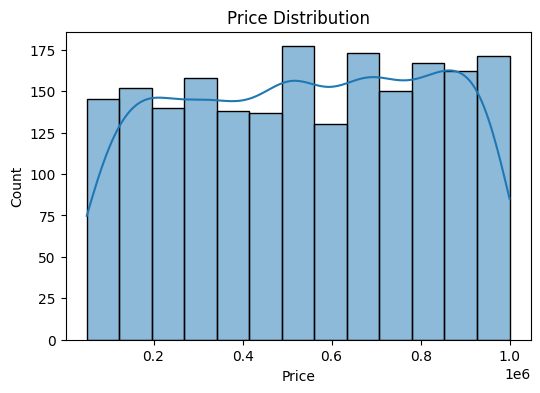

In [32]:
#Exploratory Data Analysis(EDA)
#Price Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Price"],kde=True)
plt.title("Price Distribution")
plt.show()

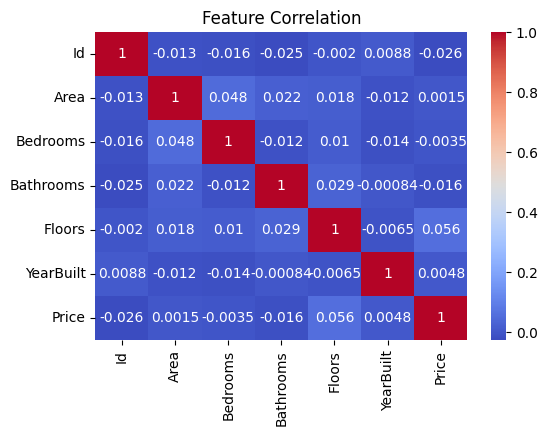

In [33]:
#correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


In [37]:
#convert text to numbers
df=pd.get_dummies(df,drop_first=True)
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


In [35]:
#Define Features and Target
X=df.drop("Price",axis=1)
y=df["Price"]
#Split Training and Testing Data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



In [38]:
#Train Machine Learning Model
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [40]:
#make predictions
predictions=model.predict(X_test)
predictions[:10]

array([511317.73109931, 557359.55652936, 482838.34523391, 540695.6411198 ,
       549288.50244107, 518144.16928401, 523405.40235976, 568346.51627797,
       556990.3977267 , 573402.71846042])

In [41]:
#Evaluate Model
mse=mean_squared_error(y_test,predictions)
r2=r2_score(y_test,predictions)
print("Mean Squared Error:",mse)
print("R-squared:",r2)

Mean Squared Error: 78279764120.86243
R-squared: -0.006181784611834162


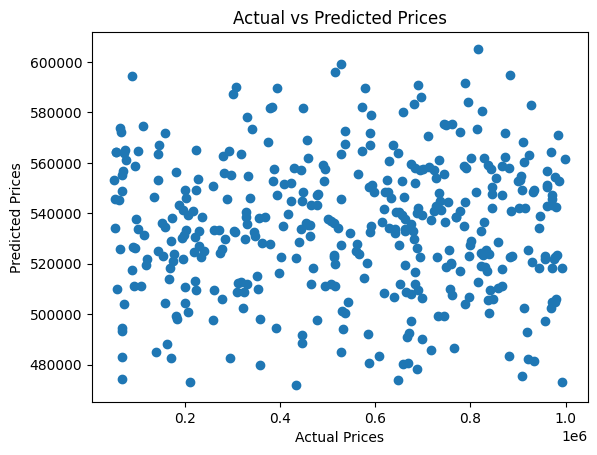

In [42]:
#compare Actual vs Predicted
plt.scatter(y_test,predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [43]:
#predicting
sample_house=X.iloc[0:1]
predicted_price=model.predict(sample_house)
print("Predicted Price:",predicted_price)

Predicted Price: [553704.61202109]
